In [4]:
import pandas as pd
df=pd.read_csv("food_orders.csv")
df

,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value,discount_applied,delivery_fee,time_taken_to_order,rating_given,is_repeat_order,mood,hunger_level,company,rainy_weather
0,1,2698,35,Pune,Evening,Weekend,Chinese,Dinner,Premium,971,Yes,90,13,1,Yes,Celebrating,High,Partner,No
1,2,3237,44,Mumbai,Night,Weekend,South Indian,Dinner,Budget,442,No,26,13,2,No,Lazy,Low,Family,No
2,3,3626,31,Delhi,Morning,Weekend,Biryani,Breakfast,Mid-range,739,Yes,85,10,2,Yes,Happy,Medium,Friends,No
3,4,3176,23,Delhi,Evening,Weekend,Biryani,Snacks,Mid-range,466,No,44,12,2,No,Happy,Medium,Alone,No
4,5,4824,26,Chandigarh,Morning,Weekday,Chinese,Lunch,Premium,927,Yes,58,13,2,No,Happy,Medium,Partner,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,3569,40,Hyderabad,Afternoon,Weekday,North Indian,Lunch,Premium,734,Yes,87,6,5,No,Happy,High,Friends,Yes
49996,49997,1087,42,Chandigarh,Morning,Weekend,Fast Food,Lunch,Mid-range,764,Yes,24,14,5,No,Happy,Low,Alone,No
49997,49998,3645,35,Pune,Morning,Weekday,South Indian,Snacks,Budget,985,Yes,53,2,5,Yes,Lazy,Medium,Alone,Yes
49998,49999,3630,34,Delhi,Morning,Weekend,Desserts,Snacks,Premium,860,Yes,48,6,3,Yes,Happy,Low,Alone,Yes


In [5]:
df.isnull().sum()

order_id               0
user_id                0
age                    0
city                   0
order_time             0
day_type               0
cuisine                0
meal_type              0
restaurant_type        0
order_value            0
discount_applied       0
delivery_fee           0
time_taken_to_order    0
rating_given           0
is_repeat_order        0
mood                   0
hunger_level           0
company                0
rainy_weather          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   order_id             50000 non-null  int64 
 1   user_id              50000 non-null  int64 
 2   age                  50000 non-null  int64 
 3   city                 50000 non-null  object
 4   order_time           50000 non-null  object
 5   day_type             50000 non-null  object
 6   cuisine              50000 non-null  object
 7   meal_type            50000 non-null  object
 8   restaurant_type      50000 non-null  object
 9   order_value          50000 non-null  int64 
 10  discount_applied     50000 non-null  object
 11  delivery_fee         50000 non-null  int64 
 12  time_taken_to_order  50000 non-null  int64 
 13  rating_given         50000 non-null  int64 
 14  is_repeat_order      50000 non-null  object
 15  mood                 50000 non-null  object
 16  hung

In [8]:
df.describe()

,order_id,user_id,age,order_value,delivery_fee,time_taken_to_order,rating_given
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,3005.466160,30.975420,547.731100,59.642720,7.496720,2.994420
std,14433.901067,1152.286323,7.804962,259.685968,23.043375,4.031059,1.413361
min,1.000000,1000.000000,18.000000,100.000000,20.000000,1.000000,1.000000
25%,12500.750000,2013.000000,24.000000,323.000000,40.000000,4.000000,2.000000
50%,25000.500000,3004.000000,31.000000,547.000000,60.000000,7.000000,3.000000
75%,37500.250000,4002.000000,38.000000,772.000000,80.000000,11.000000,4.000000
max,50000.000000,4999.000000,44.000000,999.000000,99.000000,14.000000,5.000000


In [9]:
df['city'].value_counts()

city
Mumbai        8443
Pune          8354
Bangalore     8353
Delhi         8309
Chandigarh    8279
Hyderabad     8262
Name: count, dtype: int64

In [10]:
df['order_value'].mean()

np.float64(547.7311)

In [11]:
df['order_time'].value_counts()

order_time
Evening      12550
Morning      12524
Night        12513
Afternoon    12413
Name: count, dtype: int64

In [12]:
import numpy as np
np.mean(df['order_value'])
#np.median(df['order_value'])
#np.std(df['order_value'])

np.float64(547.7311)

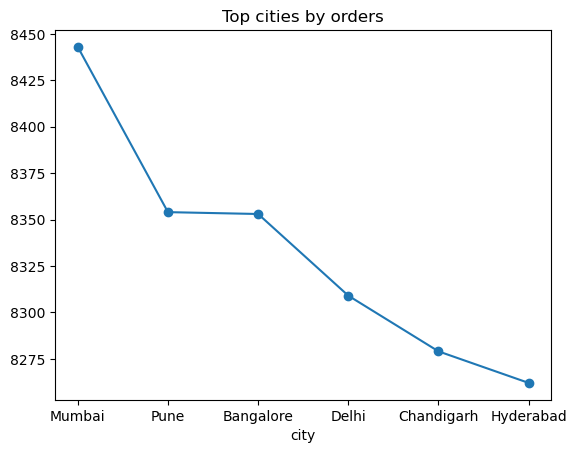

In [13]:
import matplotlib.pyplot as plt
df['city'].value_counts().plot(kind='line',marker='o')
plt.title("Top cities by orders")
plt.show()

In [14]:
df['cuisine'].value_counts()

cuisine
Desserts        8452
Fast Food       8368
Chinese         8351
South Indian    8301
Biryani         8300
North Indian    8228
Name: count, dtype: int64

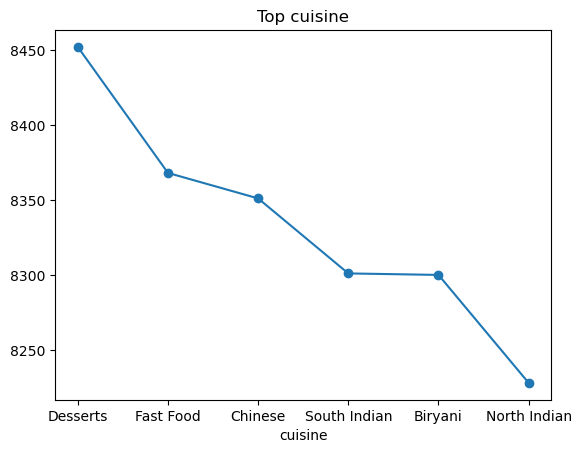

In [15]:
import matplotlib.pyplot as plt
df['cuisine'].value_counts().plot(kind='line',marker='o')
plt.title("Top cuisine")
plt.show()

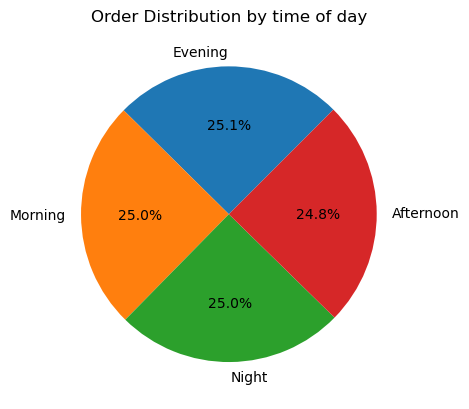

In [16]:
import matplotlib.pyplot as plt
time=df['order_time'].value_counts()
time.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=45)
plt.title("Order Distribution by time of day")
plt.ylabel("")
plt.show()
          

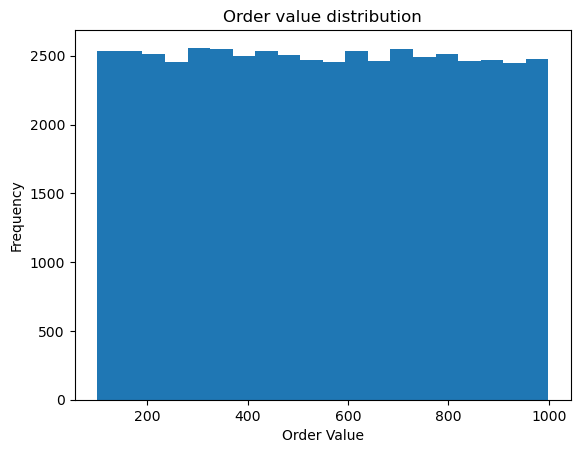

In [17]:
import matplotlib.pyplot as plt
df['order_value'].plot(kind='hist',bins=20)
plt.title("Order value distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

In [18]:
df.groupby('city')['order_value'].mean()

city
Bangalore     543.476116
Chandigarh    546.639208
Delhi         546.003129
Hyderabad     548.051440
Mumbai        549.605472
Pune          552.575174
Name: order_value, dtype: float64

In [19]:
df['order_type']=df['order_value'].apply(lambda x:'High' if x>500 else 'Low')
df['order_type'].value_counts()

order_type
High    27535
Low     22465
Name: count, dtype: int64